In [27]:
import warnings
warnings.filterwarnings("ignore")

import pyfolio as pf
import os 
import pandas as pd
from pypfopt import expected_returns
import matplotlib.pyplot as plt

import tslearn
from tslearn.clustering import TimeSeriesKMeans
from tslearn.preprocessing import TimeSeriesScalerMeanVariance

In [3]:
cd /Users/safishajjouz/GitHub/myPythonPackages

/Users/safishajjouz/GitHub/myPythonPackages


In [4]:
from myPortfolioManagement.myData import * 
from myPortfolioManagement.myPortfolioSelection import *
from myPortfolioManagement.myPortfolioOptimisation import *
from myPortfolioManagement.myPerformanceAnalytics import *

In [5]:
# read files 
# set working directory 
#os.chdir("/Users/safishajjouz/GitHub/myPortfolioManagement/files")

#fund_prices = pd.read_excel("myfunds_prices.xlsx")
#myfunds = pd.read_excel("myfunds_overview.xlsx")
#myfunds = myfunds.ISIN
#fund_prices = fund_prices[fund_prices.ISIN.isin(myfunds)]
fund_prices = load_fidelity_prices()

In [7]:
fund_prices

,fund,price,Asset_Class
Date,,,
2011-07-12,Pictet - Global Envir Opps I dy GBP,88.17,Equity
2011-07-13,Pictet - Global Envir Opps I dy GBP,88.24,Equity
2011-07-14,Pictet - Global Envir Opps I dy GBP,87.28,Equity
2011-07-15,Pictet - Global Envir Opps I dy GBP,87.53,Equity
2011-07-16,Pictet - Global Envir Opps I dy GBP,87.53,Equity
...,...,...,...
2021-12-16,WisdomTree Physical Gold GBP,127.54,Commoditities
2021-12-17,WisdomTree Physical Gold GBP,128.35,Commoditities
2021-12-18,WisdomTree Physical Gold GBP,128.35,Commoditities


In [8]:
# Clean database 
df_cleaned = fund_prices.pivot_table(index=["Date"], 
                    columns='fund', 
                    values='price')

# main data frame [this would be the starting point of the analysis]
slicde_date = "2019/05/01"


df_cleaned = df_cleaned[df_cleaned.index >= slicde_date]
df_cleaned.index = pd.to_datetime(df_cleaned.index, format='%Y/%m/%d')

# full Dataframe with Returns Cleaned
rets_all_funds = expected_returns.returns_from_prices(df_cleaned.interpolate(method = "time")) 
rets_all_funds

fund,ASI Global Inflation-Link Bd P1 Acc,Allianz Strategic Bond C Inc,Allianz Technology Trust Ord,Baillie Gifford Global Inc Growth B Acc,BlackRock European Absolute Alpha D Acc,BlackRock Throgmorton Trust Ord,BlackRock World Mining Trust Ord,Fidelity Asian Values Ord,Fidelity China Special Ord,Fidelity Global Technology W-Acc-GBP,...,Stewart Inv APAC Ldrs Sstby B GBP Acc,Threadneedle (Lux) Glb Smlr Coms GBP ZGH,Trojan Fund X Accumulation,VT Argonaut Absolute Return R GBP Acc,Vanguard FTSE Dev Wld ex-UK Eq Idx £ Acc,Vanguard Glb Bd Idx £ H Acc,WisdomTree Physical Gold GBP,iShares Core S&P 500 ETF USD Acc GBP,iShares Global Water ETF USD Dist GBP,iShares S&P SmallCap 600 ETF USD Dist GBP
Date,,,,,,,,,,,,,,,,,,,,,
2019-05-02,-0.001531,0.000878,-0.014581,-0.006831,-0.000701,0.0,-0.022099,-0.002283,-0.006160,-0.011072,...,0.001612,-0.009276,-0.005417,-0.001873,0.000238,0.000217,-0.006095,-0.009749,-0.008943,-0.009462
2019-05-03,-0.002385,-0.001128,0.001233,0.001376,0.001403,0.0,0.008475,0.006865,0.002066,0.001919,...,0.001335,0.009363,-0.001070,-0.002206,0.000780,0.000453,0.000377,0.000775,0.002753,0.010467
2019-05-04,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2019-05-05,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2019-05-06,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,-0.007663,...,0.000000,-0.006184,0.000000,0.000000,0.000000,0.000761,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-01-02,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2022-01-03,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2022-01-04,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.005391,0.000000


In [9]:
# smooth Series 
from tsmoothie.smoother import *

# Fill Missining Values 
df_cleaned.interpolate(method='time', inplace=True)


data_series = df_cleaned.transpose().to_numpy()
df_cleaned_smoothed = LowessSmoother(smooth_fraction=0.1, iterations=1)  # higher values for smooth fraction more smooth (trend)
df_cleaned_smoothed.smooth(data_series)

# generate smoothed DataFrame 
df_cleaned_sm = df_cleaned.copy()
for i in range(len(df_cleaned.columns)):
    df_cleaned_sm.iloc[:,i] = df_cleaned_smoothed.smooth_data[i]

In [10]:
df_cleaned_sm

fund,ASI Global Inflation-Link Bd P1 Acc,Allianz Strategic Bond C Inc,Allianz Technology Trust Ord,Baillie Gifford Global Inc Growth B Acc,BlackRock European Absolute Alpha D Acc,BlackRock Throgmorton Trust Ord,BlackRock World Mining Trust Ord,Fidelity Asian Values Ord,Fidelity China Special Ord,Fidelity Global Technology W-Acc-GBP,...,Stewart Inv APAC Ldrs Sstby B GBP Acc,Threadneedle (Lux) Glb Smlr Coms GBP ZGH,Trojan Fund X Accumulation,VT Argonaut Absolute Return R GBP Acc,Vanguard FTSE Dev Wld ex-UK Eq Idx £ Acc,Vanguard Glb Bd Idx £ H Acc,WisdomTree Physical Gold GBP,iShares Core S&P 500 ETF USD Acc GBP,iShares Global Water ETF USD Dist GBP,iShares S&P SmallCap 600 ETF USD Dist GBP
Date,,,,,,,,,,,,,,,,,,,,,
2019-05-01,0.586034,1.574409,1.573827,14.166027,1.435565,5.380471,3.411590,4.238767,2.254854,2.978334,...,7.506467,31.186064,1.023609,1.465475,352.175215,151.423607,92.073731,214.580746,31.868054,48.535301
2019-05-02,0.586415,1.575452,1.574797,14.181257,1.436062,5.383880,3.414912,4.241177,2.252185,2.979410,...,7.511634,31.196709,1.024322,1.467727,352.528958,151.493515,92.291577,214.809999,31.914967,48.542037
2019-05-03,0.586795,1.576500,1.575781,14.196585,1.436555,5.387301,3.418285,4.243617,2.249567,2.980534,...,7.516810,31.207651,1.025036,1.469975,352.884842,151.563406,92.509585,215.040546,31.962022,48.549194
2019-05-04,0.587174,1.577552,1.576779,14.212011,1.437043,5.390733,3.421711,4.246087,2.247002,2.981707,...,7.521995,31.218895,1.025750,1.472220,353.242891,151.633274,92.727752,215.272399,32.009215,48.556779
2019-05-05,0.587552,1.578608,1.577791,14.227536,1.437528,5.394176,3.425189,4.248588,2.244490,2.982929,...,7.527189,31.230442,1.026465,1.474460,353.603113,151.703115,92.946074,215.505561,32.056543,48.564799
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-01-02,0.687222,1.903201,3.423576,21.836891,1.731919,9.139644,5.531378,4.603657,3.085375,6.246981,...,10.629850,55.187551,1.311511,2.049017,543.466351,163.497468,128.415910,358.000994,52.669687,68.110581
2022-01-03,0.687163,1.902973,3.421761,21.842792,1.732408,9.128329,5.531060,4.599060,3.081704,6.248655,...,10.625874,55.112298,1.311615,2.050573,543.433022,163.498015,128.439136,358.104934,52.684079,68.069488
2022-01-04,0.687101,1.902747,3.419898,21.848581,1.732895,9.116977,5.530773,4.594453,3.078023,6.250332,...,10.621845,55.036706,1.311717,2.052134,543.396965,163.498375,128.462047,358.206862,52.698355,68.028121


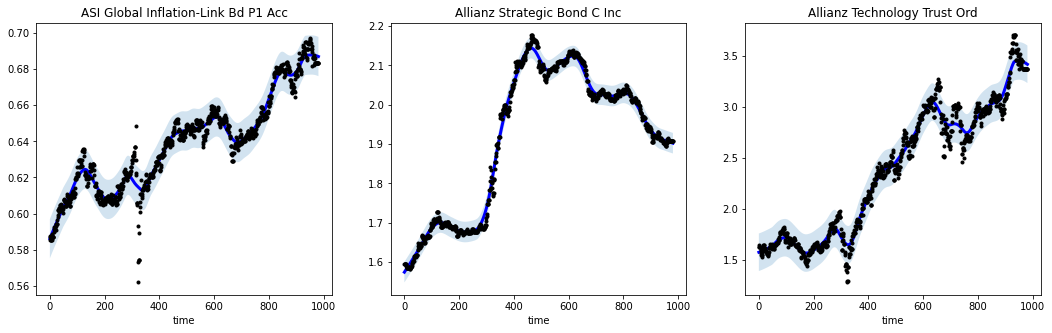

In [11]:
# Check smoothed series intervals
low, up = df_cleaned_smoothed.get_intervals('prediction_interval')

# plot the smoothed timeseries with intervals
plt.figure(figsize=(18,5))

for i in range(3):
    
    plt.subplot(1,3,i+1)
    plt.plot(df_cleaned_smoothed.smooth_data[i], linewidth=3, color='blue')
    plt.plot(df_cleaned_smoothed.data[i], '.k')
    plt.title(f"{df_cleaned.columns[i]}"); plt.xlabel('time')

    plt.fill_between(range(len(df_cleaned_smoothed.data[i])), low[i], up[i], alpha=0.2)

In [12]:
## cluster my funds

import ffn
# Implementation of David Varadi’s Fast Threshold Clustering Algorithm (FTCA).
# https://cssanalytics.wordpress.com/2013/11/26/fast-threshold-clustering-algorithm-ftca/ 
# Threshold == the threshols of correlation between assets 

ffn.core.calc_ftca(df_cleaned_sm, threshold=0.70)

{1: ['Pictet - Global Envir Opps I dy GBP',
  'ASI Global Inflation-Link Bd P1 Acc',
  'Allianz Technology Trust Ord',
  'Baillie Gifford Global Inc Growth B Acc',
  'BlackRock European Absolute Alpha D Acc',
  'BlackRock Throgmorton Trust Ord',
  'BlackRock World Mining Trust Ord',
  'Fidelity China Special Ord',
  'Fidelity Global Technology W-Acc-GBP',
  'Fundsmith Equity I Acc',
  'HarbourVest Global Priv Equity Ord',
  'HgCapital Trust Ord',
  'Invesco EQQQ NASDAQ-100 ETF GBP',
  'JPM Global Macro Opportunities C Net Acc',
  'JPMorgan China Growth & Income Ord',
  'Janus Henderson Mlt-Ast AbsRet I Acc',
  'Jupiter Strategic AbsRt Bd I £ H Acc',
  'L&G All Stocks Index Linked Gt Idx I Acc',
  'L&G Battery Value-Chain ETF GBP',
  'Merian Global Strategic Bond I GBP Acc',
  'Montanaro European Smaller Ord',
  'Pacific Horizon Ord',
  'Rathbone Ethical Bond I Inc',
  'Rathbone Global Opportunities S Acc',
  'Rathbone Multi Asset Enhanced Gr S Acc',
  'Rathbone Multi Asset Strategic Gr

In [13]:
# clustering based on returns
data_series = rets_all_funds.transpose().to_numpy()
df_cleaned_smoothed = LowessSmoother(smooth_fraction=0.1, iterations=1)  # higher values for smooth fraction more smooth (trend)
df_cleaned_smoothed.smooth(data_series)

# generate smoothed DataFrame 
returns_sm = rets_all_funds.copy()
for i in range(len(rets_all_funds.columns)):
    returns_sm.iloc[:,i] = df_cleaned_smoothed.smooth_data[i]


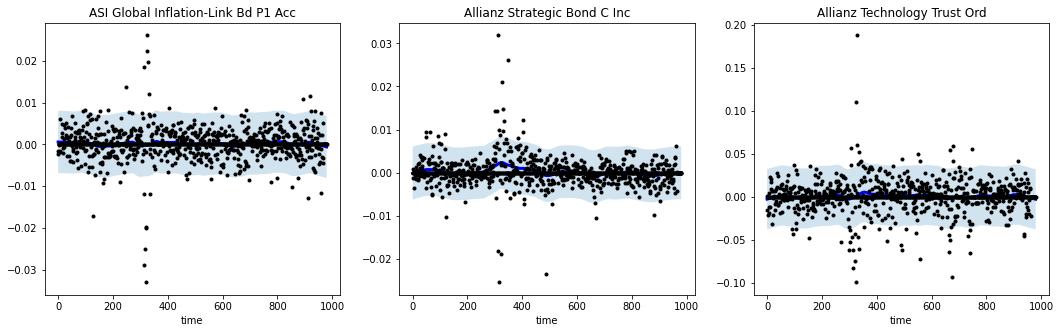

In [14]:
# Check smoothed series intervals
low, up = df_cleaned_smoothed.get_intervals('prediction_interval')

# plot the smoothed timeseries with intervals
plt.figure(figsize=(18,5))

for i in range(3):
    
    plt.subplot(1,3,i+1)
    plt.plot(df_cleaned_smoothed.smooth_data[i], linewidth=3, color='blue')
    plt.plot(df_cleaned_smoothed.data[i], '.k')
    plt.title(f"{df_cleaned.columns[i]}"); plt.xlabel('time')

    plt.fill_between(range(len(df_cleaned_smoothed.data[i])), low[i], up[i], alpha=0.2)

In [15]:
ffn.core.calc_ftca(returns_sm, threshold=0.70)

{1: ['Rathbone Global Opportunities S Acc',
  'Allianz Technology Trust Ord',
  'Baillie Gifford Global Inc Growth B Acc',
  'BlackRock Throgmorton Trust Ord',
  'Fidelity Global Technology W-Acc-GBP',
  'Fundsmith Equity I Acc',
  'HarbourVest Global Priv Equity Ord',
  'Invesco EQQQ NASDAQ-100 ETF GBP',
  'Janus Henderson Mlt-Ast AbsRet I Acc',
  'L&G Battery Value-Chain ETF GBP',
  'Montanaro European Smaller Ord',
  'Pacific Horizon Ord',
  'Pictet - Global Envir Opps I dy GBP',
  'Rathbone Ethical Bond I Inc',
  'Rathbone Multi Asset Enhanced Gr S Acc',
  'Rathbone Multi Asset Strategic Gr S Acc',
  'RobecoSAM Sustainable Water Eqs I GBP',
  'Royal London Sustainable Div C Acc',
  'Scottish Mortgage Ord',
  'Stewart Inv APAC Ldrs Sstby B GBP Acc',
  'Threadneedle (Lux) Glb Smlr Coms GBP ZGH',
  'Trojan Fund X Accumulation',
  'Vanguard FTSE Dev Wld ex-UK Eq Idx £ Acc',
  'iShares Core S&P 500 ETF USD Acc GBP',
  'iShares Global Water ETF USD Dist GBP'],
 2: ['VT Argonaut Absolute 

<AxesSubplot:xlabel='n_clusters'>

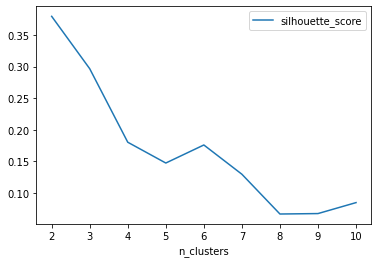

In [20]:
# find optimal clusters 
data = returns_sm.transpose().to_numpy()
data = TimeSeriesScalerMeanVariance().fit_transform(data) # standarise equivalent to 
                                                          # data = scale(data, axis = 1) from sklearn.preprocessing 

fitted_kmeans = {}
labels_kmeans = {}
df_scores = []
algo = ['dtw', 'softdtw', 'euclidean'][0]
k_values_to_try = np.arange(2, 11)

for n_clusters in k_values_to_try:
    #Perform clustering.
    kmeans = TimeSeriesKMeans(n_clusters=n_clusters, metric=algo, 
                              max_iter=100, random_state = 0)
    labels_clusters = kmeans.fit_predict(data)

    #Insert fitted model and calculated cluster labels in dictionaries,
    #for further reference.
    fitted_kmeans[n_clusters] = kmeans
    labels_kmeans[n_clusters] = labels_clusters
    
    #Calculate various scores, and save them for further reference.
    silhouette = tslearn.clustering.silhouette_score(data, labels_clusters, random_state = 0) # default metric dwt 
    
    tmp_scores = {"n_clusters": n_clusters,
                  "silhouette_score": silhouette
                  }
    df_scores.append(tmp_scores)


#Create a DataFrame of clustering scores, using `n_clusters` as index, for easier plotting.
df_scores = pd.DataFrame(df_scores)
df_scores.set_index("n_clusters", inplace=True)
df_scores.plot()

In [21]:
# optimal clustering 
optimal_n_cluster = df_scores[df_scores['silhouette_score']==max(df_scores['silhouette_score'])].index[0]
model = TimeSeriesKMeans(n_clusters=optimal_n_cluster, metric=algo, max_iter=100, random_state = 0)
y_pred = model.fit_predict(data)

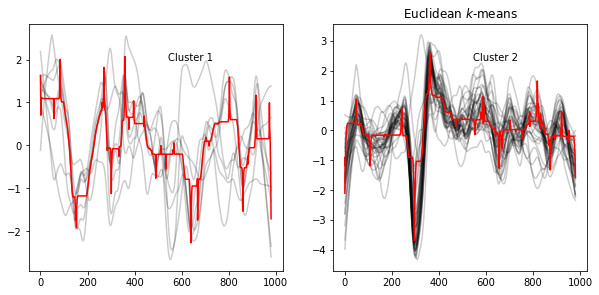

In [22]:
plt.figure(figsize= (10,10))
for yi in range(optimal_n_cluster):
    plt.subplot(optimal_n_cluster, optimal_n_cluster, yi + 1)
    for xx in data[y_pred == yi]:
        plt.plot(xx.ravel(), "k-", alpha=.2)
    plt.plot(model.cluster_centers_[yi].ravel(), "r-")
    plt.text(0.55, 0.85,'Cluster %d' % (yi + 1),
             transform=plt.gca().transAxes)
    if yi == 1:
        plt.title("Euclidean $k$-means")

In [23]:
# present reslults 
labels = model.labels_
fancy_names_for_labels = [f"Cluster {label+1}" for label in labels]
df_clusters = pd.DataFrame(zip(df_cleaned_sm.transpose().index, fancy_names_for_labels),
                           columns=["fund","Cluster"]).sort_values(by="Cluster").set_index("fund")
df_clusters

,Cluster
fund,
ASI Global Inflation-Link Bd P1 Acc,Cluster 1
WisdomTree Physical Gold GBP,Cluster 1
Vanguard Glb Bd Idx £ H Acc,Cluster 1
VT Argonaut Absolute Return R GBP Acc,Cluster 1
L&G All Stocks Index Linked Gt Idx I Acc,Cluster 1
JupiterMerian Glb Eq AbsRt I £ H Acc,Cluster 1
Merian Global Strategic Bond I GBP Acc,Cluster 1
BlackRock European Absolute Alpha D Acc,Cluster 1
Fidelity Asian Values Ord,Cluster 2


In [24]:
temp = returns_sm.transpose().merge(df_clusters, on = "fund")
temp = temp.reset_index()
temp.set_index(['fund', 'Cluster'], inplace=True)

In [25]:
returns_sm

fund,ASI Global Inflation-Link Bd P1 Acc,Allianz Strategic Bond C Inc,Allianz Technology Trust Ord,Baillie Gifford Global Inc Growth B Acc,BlackRock European Absolute Alpha D Acc,BlackRock Throgmorton Trust Ord,BlackRock World Mining Trust Ord,Fidelity Asian Values Ord,Fidelity China Special Ord,Fidelity Global Technology W-Acc-GBP,...,Stewart Inv APAC Ldrs Sstby B GBP Acc,Threadneedle (Lux) Glb Smlr Coms GBP ZGH,Trojan Fund X Accumulation,VT Argonaut Absolute Return R GBP Acc,Vanguard FTSE Dev Wld ex-UK Eq Idx £ Acc,Vanguard Glb Bd Idx £ H Acc,WisdomTree Physical Gold GBP,iShares Core S&P 500 ETF USD Acc GBP,iShares Global Water ETF USD Dist GBP,iShares S&P SmallCap 600 ETF USD Dist GBP
Date,,,,,,,,,,,,,,,,,,,,,
2019-05-02,0.000578,-0.000107,-0.002429,-0.000994,0.000861,-0.000407,-0.002827,-0.001519,-0.006412,-0.003680,...,-0.000233,-0.002049,0.000134,0.001816,-0.000512,0.000399,0.001499,-0.000968,-0.000501,-0.001508
2019-05-03,0.000578,-0.000084,-0.002340,-0.000933,0.000844,-0.000375,-0.002711,-0.001457,-0.006246,-0.003556,...,-0.000207,-0.001975,0.000149,0.001805,-0.000467,0.000401,0.001519,-0.000909,-0.000446,-0.001454
2019-05-04,0.000578,-0.000062,-0.002251,-0.000872,0.000828,-0.000345,-0.002596,-0.001394,-0.006081,-0.003433,...,-0.000182,-0.001902,0.000163,0.001793,-0.000421,0.000402,0.001539,-0.000850,-0.000391,-0.001401
2019-05-05,0.000577,-0.000039,-0.002162,-0.000813,0.000811,-0.000315,-0.002481,-0.001333,-0.005917,-0.003311,...,-0.000157,-0.001829,0.000178,0.001782,-0.000376,0.000403,0.001559,-0.000792,-0.000337,-0.001348
2019-05-06,0.000577,-0.000017,-0.002074,-0.000753,0.000795,-0.000286,-0.002368,-0.001272,-0.005754,-0.003189,...,-0.000133,-0.001757,0.000192,0.001770,-0.000332,0.000405,0.001578,-0.000734,-0.000285,-0.001295
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-01-02,-0.000534,0.000037,-0.002309,-0.000629,-0.000073,-0.001472,0.000456,-0.000854,-0.001088,0.000371,...,-0.000873,-0.001799,-0.000229,0.000985,-0.000832,-0.000170,-0.000249,-0.000643,-0.001310,-0.000917
2022-01-03,-0.000551,0.000042,-0.002380,-0.000661,-0.000086,-0.001486,0.000474,-0.000854,-0.001093,0.000373,...,-0.000894,-0.001821,-0.000240,0.000993,-0.000861,-0.000176,-0.000265,-0.000678,-0.001359,-0.000934
2022-01-04,-0.000568,0.000048,-0.002449,-0.000694,-0.000098,-0.001498,0.000492,-0.000853,-0.001097,0.000376,...,-0.000915,-0.001842,-0.000251,0.001001,-0.000889,-0.000183,-0.000281,-0.000712,-0.001407,-0.000950


<AxesSubplot:xlabel='Date'>

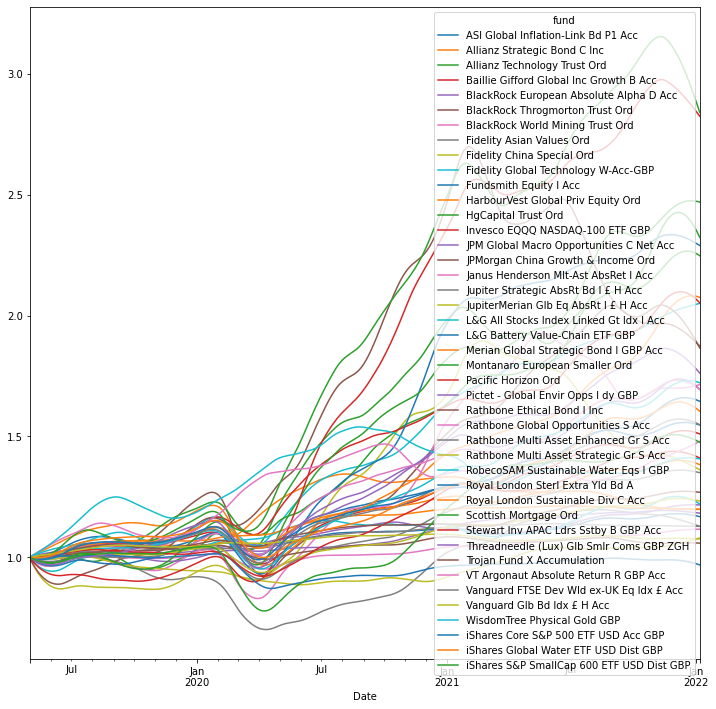

In [28]:
pf.timeseries.cum_returns(returns_sm, starting_value=1).plot(figsize=(12,12))

<AxesSubplot:>

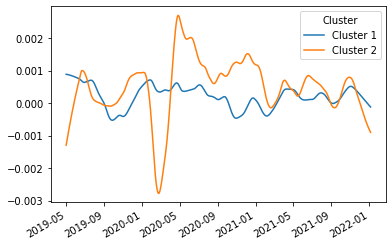

In [29]:
#calculate returns 
ret = temp.transpose()
ret = ret.droplevel('fund', axis=1)
ret = ret.transpose().reset_index()
ret.groupby('Cluster').mean().transpose().plot()


In [ ]:
ret

In [30]:
# performance summary 
import ffn
df_cluster_ret = ret.groupby('Cluster').mean().transpose()
price_index = ffn.core.to_price_index(df_cluster_ret, start=100)
perf = price_index.calc_stats()
print(perf.display())


Stat                 Cluster 1    Cluster 2
-------------------  -----------  -----------
Start                2019-05-02   2019-05-02
End                  2022-01-06   2022-01-06
Risk-free rate       0.00%        0.00%

Total Return         22.25%       61.34%
Daily Sharpe         9.45         8.61
Daily Sortino        22.74        15.86
CAGR                 7.77%        19.52%
Max Drawdown         -3.15%       -10.40%
Calmar Ratio         2.47         1.88

MTD                  -0.06%       -0.51%
3m                   2.59%        1.48%
6m                   4.01%        4.02%
YTD                  -0.06%       -0.51%
1Y                   5.50%        12.84%
3Y (ann.)            7.77%        19.52%
5Y (ann.)            -            -
10Y (ann.)           -            -
Since Incep. (ann.)  7.77%        19.52%

Daily Sharpe         9.45         8.61
Daily Sortino        22.74        15.86
Daily Mean (ann.)    5.17%        12.31%
Daily Vol (ann.)     0.55%        1.43%
Daily Skew        

In [31]:
df_cluster_ret.corr()

Cluster,Cluster 1,Cluster 2
Cluster,,
Cluster 1,1.000000,-0.003299
Cluster 2,-0.003299,1.000000


<AxesSubplot:>

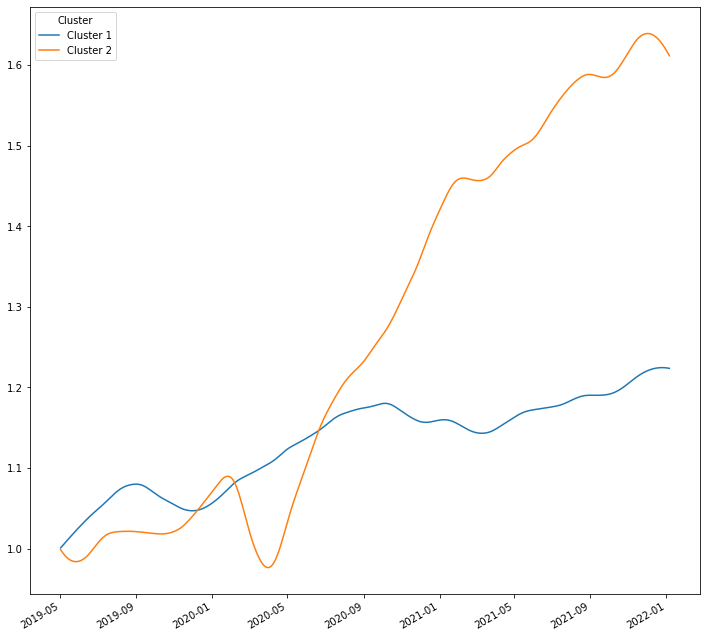

In [32]:
df_cluster_ret
pf.timeseries.cum_returns(df_cluster_ret, starting_value=1).plot(figsize=(12,12))

In [33]:
# Train Period  
# ===========
training_start_date = pd.to_datetime("2019/05/01", format='%Y/%m/%d') 
training_end_date = pd.to_datetime("2021/03/01", format='%Y/%m/%d')
rets_training = df_cluster_ret[(df_cluster_ret.index>=training_start_date) & (df_cluster_ret.index<=training_end_date)]

In [34]:
from pypfopt import HRPOpt, EfficientFrontier, objective_functions # Hierarchical Parity Optimization

hrp = HRPOpt(rets_training)
hrp.optimize()
cleaned_weights_hrp = hrp.clean_weights()
cleaned_weights_hrp = pd.DataFrame(cleaned_weights_hrp , index=[0])
cleaned_weights_hrp = pd.melt(cleaned_weights_hrp, var_name = 'fund', value_name = 'weight_hrp')
cleaned_weights_hrp

#minimum volatility 
import pypfopt
S = pypfopt.risk_models.risk_matrix(rets_training, method= "ledoit_wolf", returns_data = True)
mu = expected_returns.mean_historical_return(rets_training)

ef = EfficientFrontier(mu, S)
ef.add_objective(objective_functions.L2_reg, gamma=0.9)
ef.min_volatility()
cleaned_weights = ef.clean_weights()
cleaned_weights = pd.DataFrame(cleaned_weights , index=[0])
cleaned_weights = pd.melt(cleaned_weights, var_name = 'fund', value_name = 'weight_min_vol')
cleaned_weights

#calculate portfolio returns 
def cul_port_returns(df_returns,df_weights, portfolio_name = None):
    '''
    df_returns: a wide DataFrame series with assets returns 
    df_wegiths: a long Datafrane with Fund names in the first colum 
                and weight in the other 
    '''
    weight_name = df_weights.columns[1]
    df_weights = df_weights.sort_values("fund")
    funds = list(df_weights["fund"])
    df_returns = df_returns[funds]
    df_returns =  df_returns[sorted(df_returns.columns)]
    weights = pd.Series.to_numpy(df_weights[weight_name])
    port_returns = df_returns.fillna(0).dot(weights)  # this is a workaround due to NAs 
    if portfolio_name is None: 
        port_returns = pd.Series(port_returns, name = "portfolio")
    else:
        port_returns = pd.Series(port_returns, name = portfolio_name)
    port_returns = pd.DataFrame(port_returns)
    return port_returns

rets_all = df_cluster_ret
df_portfolios = cleaned_weights.merge(cleaned_weights_hrp, how = "left")
rets_portf_min_vol = cul_port_returns(rets_all,df_portfolios[["fund","weight_min_vol"]], portfolio_name= "portfolio_min_vol")
rets_portf_hrp = cul_port_returns(rets_all,df_portfolios[["fund","weight_hrp"]], portfolio_name= "portfolio_HRP")
rets_portf = rets_portf_hrp.merge(rets_portf_min_vol, how = "left", left_index = True, right_index= True)
rets_portf

,portfolio_HRP,portfolio_min_vol
2019-05-02,0.000607,-0.000205
2019-05-03,0.000613,-0.000177
2019-05-04,0.000619,-0.000149
2019-05-05,0.000625,-0.000122
2019-05-06,0.000631,-0.000095
...,...,...
2022-01-02,-0.000173,-0.000448
2022-01-03,-0.000185,-0.000464
2022-01-04,-0.000197,-0.000480
2022-01-05,-0.000209,-0.000495


In [35]:
returns_sm.columns

Index(['ASI Global Inflation-Link Bd P1 Acc', 'Allianz Strategic Bond C Inc',
       'Allianz Technology Trust Ord',
       'Baillie Gifford Global Inc Growth B Acc',
       'BlackRock European Absolute Alpha D Acc',
       'BlackRock Throgmorton Trust Ord', 'BlackRock World Mining Trust Ord',
       'Fidelity Asian Values Ord', 'Fidelity China Special Ord',
       'Fidelity Global Technology W-Acc-GBP', 'Fundsmith Equity I Acc',
       'HarbourVest Global Priv Equity Ord', 'HgCapital Trust Ord',
       'Invesco EQQQ NASDAQ-100 ETF GBP',
       'JPM Global Macro Opportunities C Net Acc',
       'JPMorgan China Growth & Income Ord',
       'Janus Henderson Mlt-Ast AbsRet I Acc',
       'Jupiter Strategic AbsRt Bd I £ H Acc',
       'JupiterMerian Glb Eq AbsRt I £ H Acc',
       'L&G All Stocks Index Linked Gt Idx I Acc',
       'L&G Battery Value-Chain ETF GBP',
       'Merian Global Strategic Bond I GBP Acc',
       'Montanaro European Smaller Ord', 'Pacific Horizon Ord',
       'Picte

In [36]:
rets = rets_all.join(rets_portf)

In [38]:
rets = rets.join(returns_sm[['Vanguard FTSE Dev Wld ex-UK Eq Idx £ Acc']])

In [39]:
rets

,Cluster 1,Cluster 2,portfolio_HRP,portfolio_min_vol,Vanguard FTSE Dev Wld ex-UK Eq Idx £ Acc
2019-05-02,0.000887,-0.001296,0.000607,-0.000205,-0.000512
2019-05-03,0.000886,-0.001239,0.000613,-0.000177,-0.000467
2019-05-04,0.000884,-0.001183,0.000619,-0.000149,-0.000421
2019-05-05,0.000882,-0.001126,0.000625,-0.000122,-0.000376
2019-05-06,0.000881,-0.001071,0.000631,-0.000095,-0.000332
...,...,...,...,...,...
2022-01-02,-0.000078,-0.000818,-0.000173,-0.000448,-0.000832
2022-01-03,-0.000089,-0.000840,-0.000185,-0.000464,-0.000861
2022-01-04,-0.000099,-0.000861,-0.000197,-0.000480,-0.000889
2022-01-05,-0.000110,-0.000881,-0.000209,-0.000495,-0.000917


<AxesSubplot:>

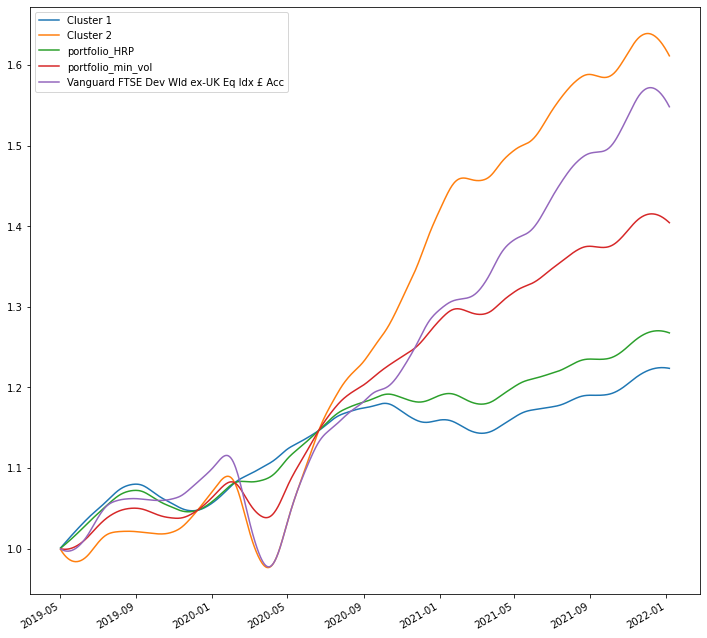

In [40]:
pf.timeseries.cum_returns(rets, starting_value=1).plot(figsize=(12,12))

In [42]:
price_index = ffn.core.to_price_index(rets, start=100)
perf = price_index[['portfolio_HRP', 'portfolio_min_vol', 'Vanguard FTSE Dev Wld ex-UK Eq Idx £ Acc']].calc_stats()
print(perf.display())

Stat                 portfolio_HRP    portfolio_min_vol    Vanguard FTSE Dev Wld ex-UK Eq Idx £ Acc
-------------------  ---------------  -------------------  ------------------------------------------
Start                2019-05-02       2019-05-02           2019-05-02
End                  2022-01-06       2022-01-06           2022-01-06
Risk-free rate       0.00%            0.00%                0.00%

Total Return         26.68%           40.45%               54.89%
Daily Sharpe         11.91            11.42                7.96
Daily Sortino        35.35            26.99                12.66
CAGR                 9.21%            13.50%               17.71%
Max Drawdown         -2.48%           -4.11%               -12.39%
Calmar Ratio         3.72             3.29                 1.43

MTD                  -0.11%           -0.28%               -0.52%
3m                   2.45%            2.03%                3.13%
6m                   4.01%            4.01%                7.34%
YTD